# Model Updates

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import torch
import deeplabcut
import DLCsupport as dlcs
import deeplabcut as dlc
import matplotlib.pyplot as plt

import glob
import xrommtools as xt
import re
import shutil


Loading DLC 3.0.0rc13...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


# Testing many models (One Truth)

In [2]:


ROOT = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate30")

METHOD_DIRS = {
    "DINO": "DinoSamplesData",
    # "Displacement": "DisplacementSamplesData",
    "Random": "RandomSamplesData",
}

SNAPSHOTS = ["s100", "s125"]
SPLITS = ["TrainT15_EvalT17", "TrainT17_EvalT15"]
NUMFRAMES = [400]
NFRAMES = [70, 90, 110]
SEED = 42
EPOCHS = 100
RUN_TRAINING = True

# Any existing video file is fine for project creation
DUMMY_VIDEO = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\TrainingData_T17\cam1_stack.avi"
)

# Base model config by training split
BASE_CONFIG_BY_SPLIT = {
    "TrainT15_EvalT17_200": Path(
        r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\Model519\n200_T15\Canari-Tyler-2026-05-22\config.yaml"
    ),
#     # "TrainT15_EvalT17_800": Path(
#     #     r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\Model519\n800_T15\Canari-Tyler-2026-05-22\config.yaml"
#     # ),
    "TrainT17_EvalT15_200": Path(
        r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\Model519\n200_T17\Canari-Tyler-2026-05-22\config.yaml"
    )
    # "TrainT17_EvalT15_800": Path(
#         r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\Model519\n800_T17\Canari-Tyler-2026-05-22\config.yaml"
#     ),
}

In [3]:
def find_truth_subset_csv(split_folder: Path) -> Path:
    hits = sorted(split_folder.glob("*TruthSubset.csv"))
    if len(hits) != 1:
        raise ValueError(f"Expected exactly 1 TruthSubset CSV in {split_folder}, found {len(hits)}")
    return hits[0]

def find_truth_subset_csv_DISPLACEMENT(split_folder: Path, nframes:int, snapshot:str) -> Path:
    split = split_folder.name
    print(split)
    hits = sorted(split_folder.glob(f"{split}_n{nframes}_{snapshot}-TruthSubset.csv"))
    print(len(hits))
    if len(hits) != 1:
        raise ValueError(f"Expected exactly 1 TruthSubset CSV in {split_folder}, found {len(hits)}")
    return hits[0]

def resolve_source_snapshot(split_name: str, snapshot_name: str, numframes) -> str:
    base_cfg = BASE_CONFIG_BY_SPLIT[f"{split_name}_{numframes}"]
    train_dir_glob = base_cfg.parent / "dlc-models-pytorch" / "iteration-0" / "*" / "train"
    train_dirs = sorted(glob.glob(str(train_dir_glob)))
    if not train_dirs:
        raise FileNotFoundError(f"No train dir found for base config: {base_cfg}")
    train_dir = Path(train_dirs[-1])
    snap_num = snapshot_name[1:]
    snap = train_dir / f"snapshot-{snap_num}.pt"
    if not snap.exists():
        raise FileNotFoundError(f"Missing source snapshot: {snap}")
    return str(snap)

def latest_snapshot_for_project(config_path: Path) -> str:
    p = config_path.parent
    g1 = p / "dlc-models-pytorch" / "iteration-0" / "*" / "train" / "snapshot-*.pt"
    g2 = p / "dlc-models-pytorch" / "iteration-0" / "*" / "train" / "snapshots" / "snapshot-*.pt"
    snaps = glob.glob(str(g1)) + glob.glob(str(g2))
    if not snaps:
        raise FileNotFoundError(f"No snapshots found under {p}")
    def epoch_key(path: str) -> int:
        m = re.search(r"snapshot(?:-best)?-(\d+)\.pt$", path.replace("\\", "/"))
        return int(m.group(1)) if m else -1
    return sorted(snaps, key=epoch_key)[-1]

def prepare_clean_trial(split_folder: Path, run_tag: str,
                         Displacement: bool = False, numframes:int = 0) -> Path:
    clean_root = split_folder / "_build" / run_tag / "clean_trial"
    if clean_root.exists():
        shutil.rmtree(clean_root)
    clean_root.mkdir(parents=True, exist_ok=True)
    Displacement = True
    if Displacement:
        snapshot = re.search(r'_(s\d+)_', run_tag)[0][1:-1]

        truth_csv = find_truth_subset_csv_DISPLACEMENT(split_folder = split_folder,
                                                        nframes= numframes,
                                                        snapshot= snapshot)
        
        filepaths_to_copy = pd.read_csv(truth_csv)['image_path']
        
        for cam in ["Cam1", "Cam2"]:
            dst = clean_root / cam
            dst.mkdir(parents=True, exist_ok=True)
         
            for filepath in filepaths_to_copy:
                if cam == "Cam2":
                    filepath = filepath.replace("cam1", "cam2")
                    filepath = filepath.replace("Cam1", "Cam2")
                filepath = Path(filepath)
                shutil.copy2(filepath, dst / filepath.name)
            
                
    else:
        for cam in ["Cam1", "Cam2"]:
            src = split_folder / cam
            dst = clean_root / cam
            if not src.exists():
                raise FileNotFoundError(f"Missing camera folder: {src}")
            shutil.copytree(src, dst)
        truth_csv = find_truth_subset_csv(split_folder)
    df = pd.read_csv(truth_csv)
    coord_cols = [c for c in df.columns if re.search(r"_cam[12]_[XY]$", c)]
    if not coord_cols:
        raise ValueError(f"No coordinate columns found in {truth_csv}")
    df[coord_cols].to_csv(clean_root / f"{run_tag}-2Dpoints.csv", index=False)
    return clean_root

def resolve_split_folder(root: Path, method_dir: str, snapshot_name: str, split_name: str) -> Path:
    # Current layout: method/snapshot/split
    p_current = root / method_dir / snapshot_name / split_name

    # Future layout: method/split/snapshot
    p_future = root / method_dir / split_name

    existing = [p for p in [p_current, p_future] if p.exists()]

    if len(existing) == 0:
        raise FileNotFoundError(
            f"No matching folder for method={method_dir}, snapshot={snapshot_name}, split={split_name}. "
            f"Tried: {p_current} and {p_future}"
        )
    if len(existing) > 1:
        raise RuntimeError(
            f"Ambiguous layout: both paths exist for method={method_dir}, snapshot={snapshot_name}, split={split_name}: "
            f"{existing}"
        )
    return existing[0]

In [4]:
def run_one_instance(method_name: str, snapshot_name: str, split_name: str, numframes: int, nframe: int) -> dict:
    ROOT = Path(rf"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate{nframe}")
    method_folder = ROOT / METHOD_DIRS[method_name]
    split_folder = method_folder / split_name

    if not split_folder.exists():
        raise FileNotFoundError(f"Missing split folder: {split_folder}")

    run_tag = f"{method_name}_{snapshot_name}_{split_name}_F{numframes}_S{SEED}"

    # Keep every artifact inside this exact split folder
    project_root = split_folder / f"ModelUpdate_{snapshot_name}_{numframes}"
    dataset_name = run_tag

    if method_name == "Displacement":
        Displacement = True
    else:
        Displacement = False
    clean_trial = prepare_clean_trial(split_folder, run_tag, Displacement = Displacement, numframes=numframes)

    combined_config = dlcs.create_combined_project_if_missing(
        task="Canari",
        experimenter="Tyler_Finetune",
        combined_project_root=project_root,
        dummy_video=DUMMY_VIDEO,
    )

    # Ensure bodyparts schema matches DavidBowie
    _ = dlcs.apply_bird_bodyparts_to_configs(
        {"DavidBowie": [combined_config]},
        strict=True,
    )

    # Avoid mixing old and new labeled-data for same dataset_name
    ds_folder = Path(combined_config).parent / "labeled-data" / dataset_name
    if ds_folder.exists():
        shutil.rmtree(ds_folder)

    dlcs.build_combined_dataset(
        combined_config=combined_config,
        data_path=clean_trial,
        dataset_name=dataset_name,
        experimenter="Tyler",
        nframes=nframe,
        frame_selection_seed=SEED,
    )

    source_snapshot = resolve_source_snapshot(split_name, snapshot_name, numframes)
    print(source_snapshot)
    trained_snapshot = None
    if RUN_TRAINING:
        try:
            trained_snapshot = dlcs.create_and_train(
                config_path=combined_config,
                epochs=100,
                snapshot_path=source_snapshot,
            )
            Models_base = combined_config.parent

            for train_dir in Models_base.glob("dlc-models-pytorch/iteration-*/*/train"):
                for file in train_dir.glob("*best*.pt"):
                    print(f"Deleting: {file}")
                    file.unlink()

        except FileNotFoundError:
            trained_snapshot = latest_snapshot_for_project(Path(combined_config))

    return {
        "method": method_name,
        "snapshot": snapshot_name,
        "split": split_name,
        "split_folder": str(split_folder),
        "combined_config": str(combined_config),
        "dataset_name": dataset_name,
        "clean_trial": str(clean_trial),
        "source_snapshot": source_snapshot,
        "trained_snapshot": trained_snapshot if trained_snapshot else "",
        "status": "ok",
    }


In [5]:
records = []
for numframe in NFRAMES:
    ROOT = Path(rf"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate{numframe}")
    for method_name in METHOD_DIRS.keys():
        for snapshot_name in SNAPSHOTS:
            for split_name in SPLITS:
                try:
                    rec = run_one_instance(method_name, snapshot_name, split_name, numframes=200, nframe = numframe)
                except Exception as e:
                    print(e)
                    rec = {
                        "method": method_name,
                        "snapshot": snapshot_name,
                        "split": split_name,
                        "status": "error",
                        "error": str(e),
                    }
                records.append(rec)
                print(rec["method"], rec["snapshot"], rec["split"], "->", rec["status"])

    manifest_df = pd.DataFrame(records)

    manifest_path = ROOT / "_manifests" / f"model_update_manifest_F{numframe}_S{SEED}.csv"
    manifest_path.parent.mkdir(parents=True, exist_ok=True)
    manifest_df.to_csv(manifest_path, index=False)

print("Saved manifest:", manifest_path)
display(manifest_df)

TrainT15_EvalT17
1
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate70\DinoSamplesData\TrainT15_EvalT17\ModelUpdate_s100_200\Canari-Tyler_Finetune-2026-07-03\videos"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate70\DinoSamplesData\TrainT15_EvalT17\ModelUpdate_s100_200\Canari-Tyler_Finetune-2026-07-03\labeled-data"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate70\DinoSamplesData\TrainT15_EvalT17\ModelUpdate_s100_200\Canari-Tyler_Finetune-2026-07-03\training-datasets"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate70\DinoSamplesData\TrainT15_EvalT17\ModelUpdate_s100_200\Canari-Tyler_Finetune-2026-07-03\dlc-models"
Attempting to create a symbolic link of the video ...
Symlin

Updated scorer in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate70\DinoSamplesData\TrainT15_EvalT17\ModelUpdate_s100_200\Canari-Tyler_Finetune-2026-07-03\config.yaml from 'Tyler_Finetune' to 'Tyler'


...done.
Training data extracted to projectpath/labeled-data. Now use deeplabcut.create_training_dataset
C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\Model519\n200_T15\Canari-Tyler-2026-05-22\dlc-models-pytorch\iteration-0\CanariMay22-trainset95shuffle1\train\snapshot-100.pt
C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate70\DinoSamplesData\TrainT15_EvalT17\ModelUpdate_s100_200\Canari-Tyler_Finetune-2026-07-03\labeled-data\cam1_stack\CollectedData_Tyler.h5  not found (perhaps not annotated).
Annotation data was not found by splitting video paths (from config['video_sets']). An alternative route is taken...
The following folders were found: ['C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\SamplesForModelUpdate70\\DinoSamplesData\\TrainT15_EvalT17\\ModelUpdate_s100_200\\Canari-Tyler_Finetune-2026-07-03\\labele

Training with configuration:
data:
  bbox_margin: 20
  colormode: RGB
  inference:
    normalize_images: True
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [0.5, 1.25]
      translation: 0
    crop_sampling:
      width: 448
      height: 448
      max_shift: 0.1
      method: hybrid
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
device: auto
inference:
  multithreading:
    enabled: True
    queue_length: 4
    timeout: 30.0
  compile:
    enabled: False
    backend: inductor
  autocast:
    enabled: False
metadata:
  project_path: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate70\DinoSamplesData\TrainT15_EvalT17\ModelUpdate_s100_200\Canari-Tyler_Finetune-2026-07-03
  pose_config_path: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate70\DinoSamplesData\TrainT15_EvalT17\ModelUpdate_s100_200\Canari-T

Deleting: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate70\DinoSamplesData\TrainT15_EvalT17\ModelUpdate_s100_200\Canari-Tyler_Finetune-2026-07-03\dlc-models-pytorch\iteration-0\CanariJul3-trainset95shuffle1\train\snapshot-best-110.pt
DINO s100 TrainT15_EvalT17 -> ok
TrainT17_EvalT15
1
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate70\DinoSamplesData\TrainT17_EvalT15\ModelUpdate_s100_200\Canari-Tyler_Finetune-2026-07-03\videos"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate70\DinoSamplesData\TrainT17_EvalT15\ModelUpdate_s100_200\Canari-Tyler_Finetune-2026-07-03\labeled-data"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate70\DinoSamplesData\TrainT17_EvalT15\ModelUpdate_s100_200\Ca

...

Updated scorer in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate110\RandomSamplesData\TrainT17_EvalT15\ModelUpdate_s125_200\Canari-Tyler_Finetune-2026-07-03\config.yaml from 'Tyler_Finetune' to 'Tyler'
INFO:root:Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


...done.
Training data extracted to projectpath/labeled-data. Now use deeplabcut.create_training_dataset
C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\Model519\n200_T17\Canari-Tyler-2026-05-22\dlc-models-pytorch\iteration-0\CanariMay22-trainset95shuffle1\train\snapshot-125.pt
C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate110\RandomSamplesData\TrainT17_EvalT15\ModelUpdate_s125_200\Canari-Tyler_Finetune-2026-07-03\labeled-data\cam1_stack\CollectedData_Tyler.h5  not found (perhaps not annotated).
Annotation data was not found by splitting video paths (from config['video_sets']). An alternative route is taken...
The following folders were found: ['C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\SamplesForModelUpdate110\\RandomSamplesData\\TrainT17_EvalT15\\ModelUpdate_s125_200\\Canari-Tyler_Finetune-2026-07-03\\

Training with configuration:
data:
  bbox_margin: 20
  colormode: RGB
  inference:
    normalize_images: True
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [0.5, 1.25]
      translation: 0
    crop_sampling:
      width: 448
      height: 448
      max_shift: 0.1
      method: hybrid
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
device: auto
inference:
  multithreading:
    enabled: True
    queue_length: 4
    timeout: 30.0
  compile:
    enabled: False
    backend: inductor
  autocast:
    enabled: False
metadata:
  project_path: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate110\RandomSamplesData\TrainT17_EvalT15\ModelUpdate_s125_200\Canari-Tyler_Finetune-2026-07-03
  pose_config_path: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate110\RandomSamplesData\TrainT17_EvalT15\ModelUpdate_s125_200\Ca

Deleting: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate110\RandomSamplesData\TrainT17_EvalT15\ModelUpdate_s125_200\Canari-Tyler_Finetune-2026-07-03\dlc-models-pytorch\iteration-0\CanariJul3-trainset95shuffle1\train\snapshot-best-130.pt
Random s125 TrainT17_EvalT15 -> ok
Saved manifest: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate110\_manifests\model_update_manifest_F110_S42.csv


,method,snapshot,split,split_folder,combined_config,dataset_name,clean_trial,source_snapshot,trained_snapshot,status
0,DINO,s100,TrainT15_EvalT17,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,DINO_s100_TrainT15_EvalT17_F200_S42,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:/Users/Salle-Cineradio/Documents/MachineLear...,ok
1,DINO,s100,TrainT17_EvalT15,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,DINO_s100_TrainT17_EvalT15_F200_S42,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:/Users/Salle-Cineradio/Documents/MachineLear...,ok
2,DINO,s125,TrainT15_EvalT17,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,DINO_s125_TrainT15_EvalT17_F200_S42,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:/Users/Salle-Cineradio/Documents/MachineLear...,ok
3,DINO,s125,TrainT17_EvalT15,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,DINO_s125_TrainT17_EvalT15_F200_S42,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:/Users/Salle-Cineradio/Documents/MachineLear...,ok
4,Random,s100,TrainT15_EvalT17,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,Random_s100_TrainT15_EvalT17_F200_S42,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:/Users/Salle-Cineradio/Documents/MachineLear...,ok
5,Random,s100,TrainT17_EvalT15,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,Random_s100_TrainT17_EvalT15_F200_S42,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:/Users/Salle-Cineradio/Documents/MachineLear...,ok
6,Random,s125,TrainT15_EvalT17,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,Random_s125_TrainT15_EvalT17_F200_S42,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:/Users/Salle-Cineradio/Documents/MachineLear...,ok
7,Random,s125,TrainT17_EvalT15,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,Random_s125_TrainT17_EvalT15_F200_S42,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:/Users/Salle-Cineradio/Documents/MachineLear...,ok
8,DINO,s100,TrainT15_EvalT17,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,DINO_s100_TrainT15_EvalT17_F200_S42,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:/Users/Salle-Cineradio/Documents/MachineLear...,ok
9,DINO,s100,TrainT17_EvalT15,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,DINO_s100_TrainT17_EvalT15_F200_S42,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:/Users/Salle-Cineradio/Documents/MachineLear...,ok


### Testing All the Trained Models 

In [ ]:
manifest_df = pd.read_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate30\_manifests\model_update_manifest_complete.csv")

In [8]:
for i in range(5):
    print(manifest_df["trained_snapshot"][i])


C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate\DinoSamplesData\TrainT15_EvalT17\ModelUpdate_s100_400\Canari-Tyler_Finetune-2026-06-10\dlc-models-pytorch\iteration-0\CanariJun10-trainset95shuffle1\train\snapshot-200.pt
C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate\DinoSamplesData\TrainT15_EvalT17\ModelUpdate_s100_800\Canari-Tyler_Finetune-2026-06-10\dlc-models-pytorch\iteration-0\CanariJun10-trainset95shuffle1\train\snapshot-200.pt
C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate\DinoSamplesData\TrainT17_EvalT15\ModelUpdate_s100_400\Canari-Tyler_Finetune-2026-06-10\dlc-models-pytorch\iteration-0\CanariJun10-trainset95shuffle1\train\snapshot-200.pt
C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate\DinoSamples

In [9]:
manifest_df = manifest_df[manifest_df['trained_snapshot'].isna() == False]


### Models Trained, Next is Model Inspection


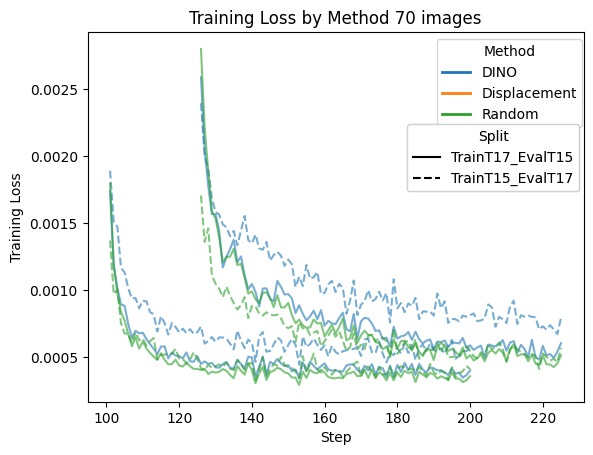

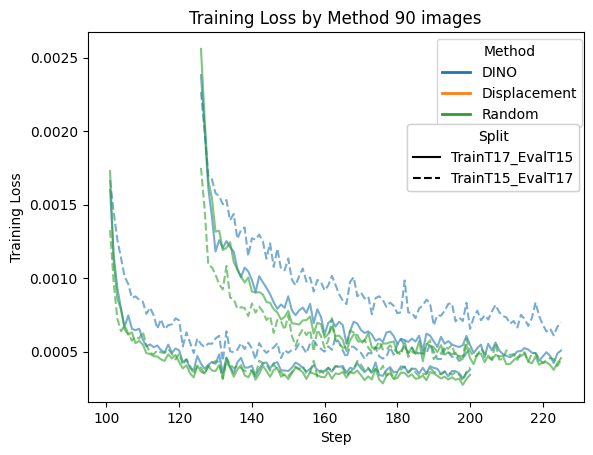

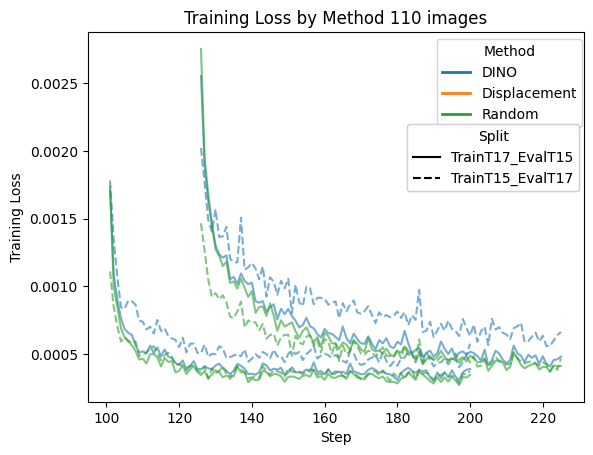

In [15]:
method_colors = {
    "DINO": "tab:blue",
    "Displacement": "tab:orange",
    "Random": "tab:green",
}

split_style = {
    "TrainT17_EvalT15": "-",
    "TrainT15_EvalT17": "--",
}

numframes_style = {
    "400" : "+",
    "800": "o"}

from matplotlib.lines import Line2D

method_legend = [
    Line2D([0], [0], color=c, lw=2, label=m)
    for m, c in method_colors.items()
]

split_legend = [
    Line2D([0], [0], color='black', linestyle=ls, label=s)
    for s, ls in split_style.items()
]

numframes_legend = [
    Line2D([0], [0], color='black', marker=mk, linestyle='None', label=n)
    for n, mk in numframes_style.items()
]

for numframe in NFRAMES:
    ROOT = Path(rf"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate{numframe}")
    manifest_df = pd.read_csv(Path(ROOT / rf"_manifests/model_update_manifest_F{numframe}_S42.csv"))
    plt.figure()
    for idx, row in manifest_df.iterrows():
        split = row["split"]
        config_path = row['combined_config']
        method = row['method']
        snapshot_path = row['trained_snapshot']
        numframes = "200" 
        try:
            learning_stats_path = Path(snapshot_path).parent / "learning_stats.csv"
            learning_stats = pd.read_csv(learning_stats_path)
            
            linestyle = split_style.get(split, "-")
            marker = numframes_style.get(numframes, "-")
            plt.plot(
                learning_stats["step"],
                learning_stats["losses/train.total_loss"],
                color=method_colors.get(method, "black"),
                linestyle=linestyle,
                # marker=marker,
                # markevery=20,   # marker every 20th point
                # markersize=4,
                label=method,
                alpha = .6
            )
            
        except Exception as e:
            print(e)
            
    plt.xlabel("Step")
    plt.ylabel("Training Loss")
    plt.title(f"Training Loss by Method {numframe} images")
    # handles, labels = plt.gca().get_legend_handles_labels()
    ax = plt.gca()
    legend1 = ax.legend(
        handles=method_legend,
        title="Method",
        loc="upper left",
        bbox_to_anchor=(.69, 1.0),
        frameon=True,
    )
    ax.add_artist(legend1)

    legend2 = ax.legend(
        handles=split_legend,
        title="Split",
        loc="upper left",
        bbox_to_anchor=(.63, 0.77),
        frameon=True,
    )
    ax.add_artist(legend2)

    # ax.legend(
    #     handles=numframes_legend,
    #     title="num_frames",
    #     loc="upper left",
    #     bbox_to_anchor=(.78, 0.6),
    #     frameon=True,
    # )

    # by_label = dict(zip(labels, handles))
    # plt.legend(by_label.values(), by_label.keys())
    plt.show()

In [ ]:
# manifest_df["trained_snapshot"] = (
#     manifest_df["trained_snapshot"]
#     .astype(str)
#     .str.replace("-best", "", regex=False)
# )

### Make Predictions

In [19]:
for numframe in NFRAMES:
    print(numframe)
    ROOT = Path(rf"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate{numframe}")
    manifest_df = pd.read_csv(Path(ROOT / rf"_manifests/model_update_manifest_F{numframe}_S42.csv"))

    for idx, row in manifest_df.iterrows():
        
        split = row["split"]
        config_path = row['combined_config']
        method = row['method']
        # print(split)
        # print(method)
        if method == "Displacement":
            continue
        snapshot_path = row['trained_snapshot']
        print(snapshot_path)
        numframes = "200" 
        eval_val = re.search(r"_EvalT(\d+)", split)[0][-2:]
        snapshot = re.search(r"snapshot-(\d+)", str(snapshot_path))[0][-3:]
        method_folder = METHOD_DIRS[method]
        # print(snapshot)

        root = Path(snapshot_path).parent
        for file in root.rglob("*best*.pt"):
            print(f"Deleting: {file}")
            file.unlink()
        dlc.analyze_videos(
            str(config_path),
            [str(Path(rf"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\TrainingData_T{eval_val}\cam1_stack.avi")), str(Path(rf"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\TrainingData_T{eval_val}\cam2_stack.avi"))],
            save_as_csv=True,
            destfolder=rf"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate{numframe}\{method_folder}\{split}\TunedPredictions\{numframes}"
        )

        # Make sure date matches!
        xt.dlc_to_xma(
            rf"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate{numframe}\{method_folder}\{split}\TunedPredictions\{numframes}\cam1_stackDLC_Resnet50_CanariJul3shuffle1_snapshot_{snapshot}.csv", 
            rf"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate{numframe}\{method_folder}\{split}\TunedPredictions\{numframes}\cam2_stackDLC_Resnet50_CanariJul3shuffle1_snapshot_{snapshot}.csv", 
            f"s{snapshot}", 
            rf"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate{numframe}\{method_folder}\{split}\TunedPredictions")
        

        # Predicted_xmalab = pd.read_csv(rf"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate30\\{METHOD_DIRS[method]}\{split}\TunedPredictions\{numframes}\s{snapshot}-Predicted2DPoints.csv")

70
C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut2/DavidBowie/SamplesForModelUpdate70/DinoSamplesData/TrainT15_EvalT17/ModelUpdate_s100_200/Canari-Tyler_Finetune-2026-07-03/dlc-models-pytorch/iteration-0\CanariJul3-trainset95shuffle1\train\snapshot-200.pt
Creating the output folder C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate70\DinoSamplesData\TrainT15_EvalT17\TunedPredictions\200
Analyzing videos with C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate70\DinoSamplesData\TrainT15_EvalT17\ModelUpdate_s100_200\Canari-Tyler_Finetune-2026-07-03\dlc-models-pytorch\iteration-0\CanariJul3-trainset95shuffle1\train\snapshot-200.pt
Using scorer: DLC_Resnet50_CanariJul3shuffle1_snapshot_200
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\TrainingData_T1

100%|██████████| 1560/1560 [00:44<00:00, 34.75it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate70\DinoSamplesData\TrainT15_EvalT17\TunedPredictions\200\cam1_stackDLC_Resnet50_CanariJul3shuffle1_snapshot_200.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate70\DinoSamplesData\TrainT15_EvalT17\TunedPredictions\200\cam1_stackDLC_Resnet50_CanariJul3shuffle1_snapshot_200_full.pickle
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\TrainingData_T17\cam2_stack.avi
Video metadata: 
  Overall # of frames:    1560
  Duration of video [s]:  3.12
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 8


100%|██████████| 1560/1560 [00:44<00:00, 34.78it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate70\DinoSamplesData\TrainT15_EvalT17\TunedPredictions\200\cam2_stackDLC_Resnet50_CanariJul3shuffle1_snapshot_200.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate70\DinoSamplesData\TrainT15_EvalT17\TunedPredictions\200\cam2_stackDLC_Resnet50_CanariJul3shuffle1_snapshot_200_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.

C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut2/DavidBowie/SamplesForModelUpdate70/DinoSamplesData/TrainT17_EvalT15/ModelUpdate_s100_200/Canari-Tyler_Finetun

...

Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate110\RandomSamplesData\TrainT15_EvalT17\TunedPredictions\200\cam1_stackDLC_Resnet50_CanariJul3shuffle1_snapshot_225.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate110\RandomSamplesData\TrainT15_EvalT17\TunedPredictions\200\cam1_stackDLC_Resnet50_CanariJul3shuffle1_snapshot_225_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.

C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut2/DavidBowie/SamplesForModelUpdate110/RandomSamplesData/TrainT17_EvalT15/ModelUpdate_s125_200/Canari-Tyle

100%|██████████| 2980/2980 [01:26<00:00, 34.37it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate110\RandomSamplesData\TrainT17_EvalT15\TunedPredictions\200\cam2_stackDLC_Resnet50_CanariJul3shuffle1_snapshot_225.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate110\RandomSamplesData\TrainT17_EvalT15\TunedPredictions\200\cam2_stackDLC_Resnet50_CanariJul3shuffle1_snapshot_225_full.pickle
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\TrainingData_T15\cam1_stack.avi
Video metadata: 
  Overall # of frames:    2980
  Duration of video [s]:  5.96
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 8


100%|██████████| 2980/2980 [01:26<00:00, 34.34it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate110\RandomSamplesData\TrainT17_EvalT15\TunedPredictions\200\cam1_stackDLC_Resnet50_CanariJul3shuffle1_snapshot_225.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate110\RandomSamplesData\TrainT17_EvalT15\TunedPredictions\200\cam1_stackDLC_Resnet50_CanariJul3shuffle1_snapshot_225_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.



In [20]:
def _xmalab_wide_to_long(df: pd.DataFrame, value_prefix: str) -> pd.DataFrame:
    """Convert a wide XMALab table to long format used by the overlay viewer.

    Expected source columns:
        <bodypart>_cam1_X, <bodypart>_cam1_Y, <bodypart>_cam2_X, <bodypart>_cam2_Y
        (same pattern for every bodypart)

    Args:
        df: Wide table where each row is one frame/row position.
        value_prefix: Prefix used in output value columns, e.g. 'pred' or 'true'.

    Returns:
        Long DataFrame with columns:
            row_pos, bodypart, camera, x_<value_prefix>, y_<value_prefix>

    Raises:
        ValueError: If no XMALab-style columns are detected.
    """
    rows = []
    for col in df.columns:
        m = re.match(r"(?P<bodypart>.+)_cam(?P<cam>[12])_(?P<coord>[XY])$", str(col))
        if m is None:
            continue
        rows.append((m.group("bodypart"), f"cam{m.group('cam')}", m.group("coord").lower(), col))

    if not rows:
        raise ValueError("Could not parse XMALab columns (expected '*_cam[12]_[XY]').")

    meta = pd.DataFrame(rows, columns=["bodypart", "camera", "coord", "column"])
    xmeta = meta[meta["coord"] == "x"].rename(columns={"column": "xcol"})
    ymeta = meta[meta["coord"] == "y"].rename(columns={"column": "ycol"})
    pairs = xmeta.merge(ymeta[["bodypart", "camera", "ycol"]], on=["bodypart", "camera"], how="inner")

    row_pos = np.arange(len(df), dtype=int)
    parts = []
    for _, r in pairs.iterrows():
        parts.append(
            pd.DataFrame(
                {
                    "row_pos": row_pos,
                    "bodypart": r["bodypart"],
                    "camera": r["camera"],
                    f"x_{value_prefix}": pd.to_numeric(df[r["xcol"]], errors="coerce"),
                    f"y_{value_prefix}": pd.to_numeric(df[r["ycol"]], errors="coerce"),
                }
            )
        )

    if not parts:
        return pd.DataFrame(columns=["row_pos", "bodypart", "camera", f"x_{value_prefix}", f"y_{value_prefix}"])
    return pd.concat(parts, ignore_index=True)

In [48]:
manifest_df_nodsiplacement = manifest_df[manifest_df['split_folder'].isna() == False]

manifest_df_nodsiplacement= manifest_df[manifest_df["method"] != "Displacement"]

In [26]:
prediction_paths = []
rmses = []
num_frames = []
for numframe in NFRAMES:
    prediction_paths = []
    rmses = []
    num_frames = []
    ROOT = Path(rf"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate{numframe}")
    manifest_df = pd.read_csv(Path(ROOT / rf"_manifests/model_update_manifest_F{numframe}_S42.csv"))
    
    manifest_df_nodsiplacement = manifest_df[manifest_df['split_folder'].isna() == False]
    manifest_df_nodsiplacement= manifest_df[manifest_df["method"] != "Displacement"]
    for idx, row in manifest_df_nodsiplacement.iterrows():
        split = row["split"]
        config_path = row['combined_config']
        method = row['method']
        # if method == "Displacement":
        #     continue
        snapshot_path = row['trained_snapshot']
        if snapshot_path == 'NaN':
            continue
        # print(snapshot_path)
        numframes = "200"
        eval_val = re.search(r"_EvalT(\d+)", split)[0][-2:]
        
        snapshot = re.search(r"snapshot-(\d+)", snapshot_path)[0][-3:]
        # print(eval_val, numframes, snapshot)
        Predicted_xmalab = pd.read_csv(rf"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate{numframe}\\{METHOD_DIRS[method]}\{split}\TunedPredictions\s{snapshot}-Predicted2DPoints.csv")
        print(split)
        print(eval_val)
        truth_xmalab = pd.read_csv(rf"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\TrainingData_T{eval_val}\LabeledBodyPartsCoordinates.csv")
        pred_long = _xmalab_wide_to_long(Predicted_xmalab, "pred")
        truth_long = _xmalab_wide_to_long(truth_xmalab, "true")
        # Direct comparison: join on row_pos/bodypart/camera in the same schema.
        merged = pred_long.merge(truth_long, on=["row_pos", "bodypart", "camera"], how="inner")
        merged = merged.dropna(subset=["row_pos", "x_pred", "y_pred", "x_true", "y_true"]).copy()

        # print(
        #     f"Row overlap: pred_rows={len(Predicted_xmalab)} truth_rows={len(truth_xmalab)} merged_points={len(merged)}"
        # )

        if merged.empty:
            print("Merged table is empty; skipping metrics for this run.")
            continue

        merged["distance_px"] = np.sqrt(
            (merged["x_pred"] - merged["x_true"]) ** 2 + (merged["y_pred"] - merged["y_true"]) ** 2
        )

        rmse = float(np.sqrt(np.mean(np.square(merged["distance_px"]))))
        # distances = np.linalg.norm(errors, axis=2)
        # rmse1 = np.sqrt(np.mean(distances**2))
        # rmse2 = np.sqrt(np.mean((Predicted_xmalab-truth_xmalab)**2))
        num_frames.append(numframes)
        rmses.append(rmse)
        # print(rmse2)
        prediction_paths.append(rf"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate{numframe}\\{METHOD_DIRS[method]}\{split}\TunedPredictions\{numframes}\s{snapshot}-Predicted2DPoints.csv") 
    manifest_df_nodsiplacement["RMSE"] = rmses
    manifest_df_nodsiplacement['prediction_paths'] = prediction_paths
    manifest_df_nodsiplacement['num_frames_orig'] = num_frames
    manifest_df_nodsiplacement['nframe_update'] = numframe
    manifest_df_nodsiplacement.to_csv(rf"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate{numframe}\_manifests\whole_manifest_F{numframe}_S42.csv")
        
        

TrainT15_EvalT17
17
TrainT17_EvalT15
15
TrainT15_EvalT17
17
TrainT17_EvalT15
15
TrainT15_EvalT17
17
TrainT17_EvalT15
15
TrainT15_EvalT17
17
TrainT17_EvalT15
15
TrainT15_EvalT17
17
TrainT17_EvalT15
15
TrainT15_EvalT17
17
TrainT17_EvalT15
15
TrainT15_EvalT17
17
TrainT17_EvalT15
15
TrainT15_EvalT17
17
TrainT17_EvalT15
15
TrainT15_EvalT17
17
TrainT17_EvalT15
15
TrainT15_EvalT17
17
TrainT17_EvalT15
15
TrainT15_EvalT17
17
TrainT17_EvalT15
15
TrainT15_EvalT17
17
TrainT17_EvalT15
15


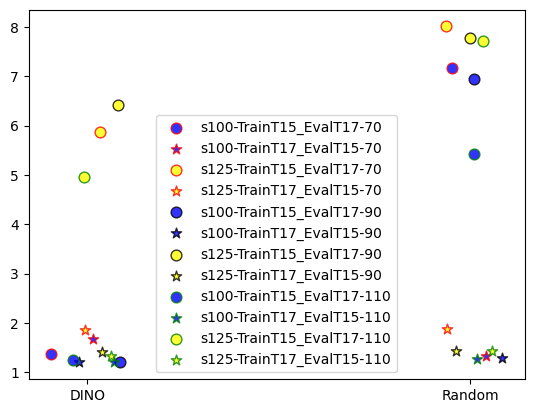

In [35]:
numframe_style = {
    "70": "red",
    "90": "black",
    "110": "green"
}

snap_style = {
    "s100": "blue",
    # "s200": "green",
    "s125": "yellow",
    # "s150": "orange",
}

split_style = {
    "TrainT17_EvalT15": "*",
    "TrainT15_EvalT17": "o",
}


for nframe in NFRAMES:
    ROOT = Path(rf"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate{nframe}")
    manifest_df = pd.read_csv(Path(ROOT / rf"_manifests/whole_manifest_F{nframe}_S42.csv"))
    
    for (snap, splt, numfram), df in manifest_df.groupby(["snapshot", "split", "nframe_update"]):

        x = df["method"].astype("category").cat.codes
        x = x + np.random.uniform(-0.1, 0.1, len(df))

        plt.scatter(
            x,
            df["RMSE"],
            color=snap_style.get(str(snap), "black"),
            marker=split_style.get(str(splt), "o"),
            edgecolors=numframe_style.get(str(numfram), "black"),
            s = 60,
            alpha=0.8,
            label=f"{snap}-{splt}-{numfram}"

        )
    

    methods = manifest_df_nodsiplacement["method"].astype("category")
    plt.xticks(range(len(methods.cat.categories)), methods.cat.categories)
# # Legend: Snapshot (fill color)
# color_handles = [
#     Line2D(
#         [0], [0],
#         marker="o",
#         linestyle="",
#         markerfacecolor=color,
#         markeredgecolor="black",
#         markersize=8,
#         label=snap,
#     )
#     for snap, color in snap_style.items()
# ]

# # Legend: Split (marker shape)
# marker_handles = [
#     Line2D(
#         [0], [0],
#         marker=marker,
#         linestyle="",
#         color="black",
#         markersize=8,
#         label=split,
#     )
#     for split, marker in split_style.items()
# ]

# # Legend: Num frames (edge color)
# edge_handles = [
#     Line2D(
#         [0], [0],
#         marker="o",
#         linestyle="",
#         markerfacecolor="white",
#         markeredgecolor=edgecolor,
#         markersize=8,
#         label=str(numframes),
#     )
#     for numframes, edgecolor in numframe_style.items()
# ]

# leg1 = ax.legend(handles=color_handles, title="Snapshot", loc="best", bbox_to_anchor=(0.1, 1.0))
# ax.add_artist(leg1)

# leg2 = ax.legend(handles=marker_handles, title="Split", loc="best", bbox_to_anchor=(0.4, 1))
# ax.add_artist(leg2)

# ax.legend(handles=edge_handles, title="Num Frames", loc="best", bbox_to_anchor=(0.21, 1))

plt.legend()
plt.show()

### Comparison with the old

In [54]:
# New column of RMSE for UnUpdated


Full_summary_noupdates = pd.read_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DB_END_COMBINED_EVAL\subepochs_summary.csv")

# display(Full_summary_noupdates)
subset_noupdates = Full_summary_noupdates[
    Full_summary_noupdates["numframes"].isin([400, 800]) &
    (Full_summary_noupdates["eval_trial"] != Full_summary_noupdates["train_trial"]) &
    Full_summary_noupdates["snapshot_num"].isin([125, 150, 100, 200])
]
subset_noupdates['method'] = "UnUpdated"
subset_noupdates = subset_noupdates[['pair_slug', 'numframes', 'snapshot_num', 'rmse_px', 'method']]
subset_noupdates = subset_noupdates.rename({"pair_slug" : "split",
                         "rmse_px" : "RMSE",
                         "snapshot_num" : 'snapshot',
                         "numframes" : "num_frames_orig"}, axis = 1)
subset_noupdates

C:\Users\Salle-Cineradio\AppData\Local\Temp\ipykernel_25044\583062487.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_noupdates['method'] = "UnUpdated"


,split,num_frames_orig,snapshot,RMSE,method
15,TrainT15_EvalT17,400,100,9.962041,UnUpdated
16,TrainT15_EvalT17,400,125,9.029477,UnUpdated
17,TrainT15_EvalT17,400,150,9.361101,UnUpdated
18,TrainT15_EvalT17,800,100,8.690312,UnUpdated
19,TrainT15_EvalT17,800,125,8.790377,UnUpdated
20,TrainT15_EvalT17,800,150,9.974571,UnUpdated
27,TrainT17_EvalT15,400,100,7.675016,UnUpdated
28,TrainT17_EvalT15,400,125,7.085597,UnUpdated
29,TrainT17_EvalT15,400,150,7.293461,UnUpdated
30,TrainT17_EvalT15,800,100,6.915383,UnUpdated


In [55]:
subset_noupdates["snapshot"] = "s" + subset_noupdates["snapshot"].astype(str)

In [56]:
# manifest_df.to_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate30\_manifests\AdditionalTrainingResults.csv")
manifest_df_subset = manifest_df_nodsiplacement[['split', 'num_frames_orig', 'snapshot', 'RMSE', "method"]]
manifest_df_subset

,split,num_frames_orig,snapshot,RMSE,method
0,TrainT15_EvalT17,400,s100,5.167437,DINO
1,TrainT15_EvalT17,800,s100,4.890768,DINO
2,TrainT17_EvalT15,400,s100,1.326770,DINO
3,TrainT17_EvalT15,800,s100,1.238336,DINO
4,TrainT15_EvalT17,400,s125,4.473542,DINO
5,TrainT15_EvalT17,800,s125,6.182477,DINO
6,TrainT17_EvalT15,400,s125,1.948016,DINO
7,TrainT17_EvalT15,800,s125,2.058860,DINO
8,TrainT15_EvalT17,400,s150,4.591585,DINO
9,TrainT15_EvalT17,800,s150,6.246181,DINO


In [57]:
comparison_df = pd.concat([manifest_df_subset, subset_noupdates], ignore_index=True)
display(comparison_df)

,split,num_frames_orig,snapshot,RMSE,method
0,TrainT15_EvalT17,400,s100,5.167437,DINO
1,TrainT15_EvalT17,800,s100,4.890768,DINO
2,TrainT17_EvalT15,400,s100,1.326770,DINO
3,TrainT17_EvalT15,800,s100,1.238336,DINO
4,TrainT15_EvalT17,400,s125,4.473542,DINO
5,TrainT15_EvalT17,800,s125,6.182477,DINO
6,TrainT17_EvalT15,400,s125,1.948016,DINO
7,TrainT17_EvalT15,800,s125,2.058860,DINO
8,TrainT15_EvalT17,400,s150,4.591585,DINO
9,TrainT15_EvalT17,800,s150,6.246181,DINO


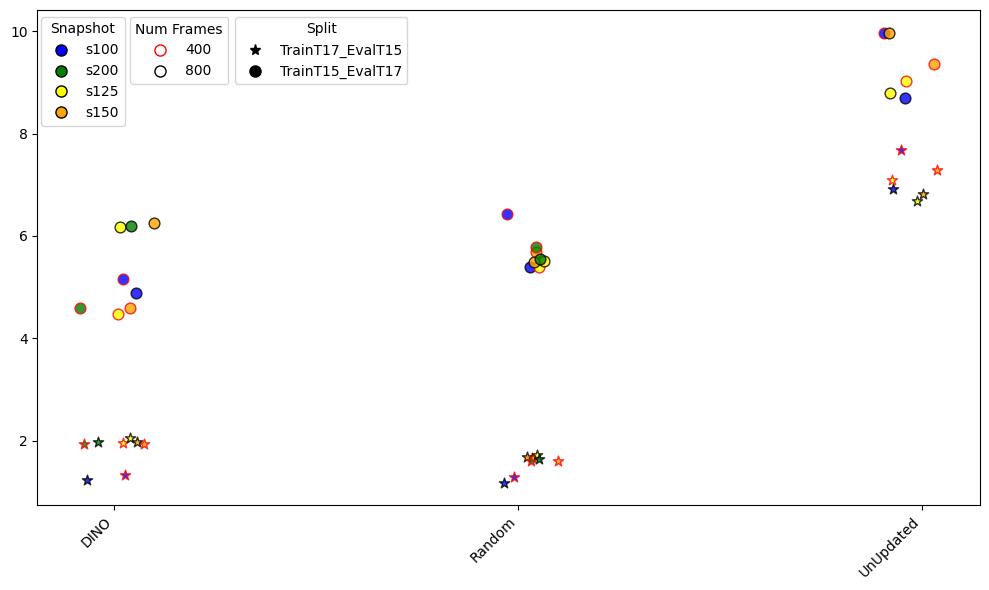

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

numframes_style = {
    "400": "red",
    "800": "black",
}

snap_style = {
    "s100": "blue",
    "s200": "green",
    "s125": "yellow",
    "s150": "orange",
}

split_style = {
    "TrainT17_EvalT15": "*",
    "TrainT15_EvalT17": "o",
}

# Create a global method -> x-position mapping
methods = sorted(comparison_df["method"].dropna().unique())
method_to_x = {method: i for i, method in enumerate(methods)}

fig, ax = plt.subplots(figsize=(10, 6))

for (snap, splt, numfram), df in comparison_df.groupby(
    ["snapshot", "split", "num_frames_orig"]
):
    x = df["method"].map(method_to_x).astype(float)
    x += np.random.uniform(-0.1, 0.1, len(df))  # jitter

    ax.scatter(
        x,
        df["RMSE"],
        color=snap_style.get(str(snap), "black"),
        marker=split_style.get(str(splt), "o"),
        edgecolors=numframes_style.get(str(numfram), "black"),
        s=60,
        alpha=0.8,
    )

# X-axis labels
ax.set_xticks(range(len(methods)))
ax.set_xticklabels(methods, rotation=45, ha="right")

# Legend: Snapshot (fill color)
color_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=color,
        markeredgecolor="black",
        markersize=8,
        label=snap,
    )
    for snap, color in snap_style.items()
]

# Legend: Split (marker shape)
marker_handles = [
    Line2D(
        [0], [0],
        marker=marker,
        linestyle="",
        color="black",
        markersize=8,
        label=split,
    )
    for split, marker in split_style.items()
]

# Legend: Num frames (edge color)
edge_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor="white",
        markeredgecolor=edgecolor,
        markersize=8,
        label=str(numframes),
    )
    for numframes, edgecolor in numframes_style.items()
]

leg1 = ax.legend(handles=color_handles, title="Snapshot", loc="best", bbox_to_anchor=(0.1, 1.0))
ax.add_artist(leg1)

leg2 = ax.legend(handles=marker_handles, title="Split", loc="best", bbox_to_anchor=(0.4, 1))
ax.add_artist(leg2)

ax.legend(handles=edge_handles, title="Num Frames", loc="best", bbox_to_anchor=(0.21, 1))

plt.tight_layout()
plt.show()


